# Cairo Metro Network Analysis

## Social Networks Project

### Prepared by:
- Your Name

### Dataset Source:
GTFS Cairo Metro Dataset

### Project Objectives
This project analyzes the Cairo Metro system as a complex transportation network using NetworkX.

The analysis includes:
- Degree Distribution
- Centrality Analysis
- Robustness Testing
- Community Detection
- Spread Simulation

In [115]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.style.use("ggplot")
stops = pd.read_csv("data/stops.txt")
stop_times = pd.read_csv("data/stop_times.txt")
routes = pd.read_csv("data/routes.txt")
trips = pd.read_csv("data/trips.txt")

# Dataset Acquisition

The dataset was obtained from the Cairo Metro GTFS repository.

The dataset contains:
- Metro stations
- Routes
- Trips
- Stop sequences

In [116]:
display(stops.head())
display(stop_times.head())
display(routes.head())
display(trips.head())

,stop_id,stop_name,stop_desc,stop_lat,stop_lon,location_type,parent_station,wheelchair_boarding
0,10_HLW_METRO_N,Helwan,NaN,29.848824,31.334252,NaN,10_HLW_METRO,NaN
1,10_AHL_METRO_N,Ain Helwan,NaN,29.862604,31.325026,NaN,10_AHL_METRO,NaN
2,10_UHL_METRO_N,Helwan University,NaN,29.869452,31.320004,NaN,10_UHL_METRO,NaN
3,14_HOF_METRO_N,Wadi Hof,NaN,29.879053,31.313438,NaN,14_HOF_METRO,NaN
4,14_HHL_METRO_N,Hadayek Helwan,NaN,29.897192,31.304040,NaN,14_HHL_METRO,NaN


,trip_id,arrival_time,departure_time,stop_id,stop_sequence,stop_headsign,pickup_type,drop_off_type,timepoint
0,T_L1_N,6:00:00,6:00:15,10_HLW_METRO_N,1,NaN,NaN,NaN,NaN
1,T_L1_N,6:02:15,6:02:40,10_AHL_METRO_N,2,NaN,NaN,NaN,NaN
2,T_L1_N,6:04:40,6:05:05,10_UHL_METRO_N,3,NaN,NaN,NaN,NaN
3,T_L1_N,6:07:05,6:07:30,14_HOF_METRO_N,4,NaN,NaN,NaN,NaN
4,T_L1_N,6:09:30,6:09:55,14_HHL_METRO_N,5,NaN,NaN,NaN,NaN


,route_id,agency_id,route_short_name,route_long_name,route_desc,route_type,route_url,route_color,route_text_color
0,L1,NAT,M1,Metro Line 1,Helwan - El Marg,1,NaN,NaN,NaN
1,L3,NAT,M3,Metro Line 3,Attaba - Al Ahram,1,NaN,NaN,NaN
2,L2,NAT,M2,Metro Line 2,Shobra El Kheima - El Mounib,1,NaN,NaN,NaN


,route_id,service_id,trip_id,trip_short_name,direction_id,wheelchair_accessible
0,L1,DAILY,T_L1_N,Helwan - El Marg,0,1
1,L3,DAILY,T_L3_E,Attaba - Ahram,0,1
2,L1,DAILY,T_L1_S,El Marg - Helwan,1,1
3,L3,DAILY,T_L3_W,Ahram - Attaba,1,1
4,L2,DAILY,T_L2_S,El Mounib - Shobra El Kheima,0,1


In [117]:
#Dataset Basic Information
print("Stops rows:", stops.shape[0])
print("Stop times rows:", stop_times.shape[0])
print("Routes rows:", routes.shape[0])
print("Trips rows:", trips.shape[0])

print("\nStops columns:")
print(stops.columns)

print("\nStop times columns:")
print(stop_times.columns)

Stops rows: 189
Stop times rows: 128
Routes rows: 3
Trips rows: 6

Stops columns:
Index(['stop_id', 'stop_name', 'stop_desc', 'stop_lat', 'stop_lon',
       'location_type', 'parent_station', 'wheelchair_boarding'],
      dtype='str')

Stop times columns:
Index(['trip_id', 'arrival_time', 'departure_time', 'stop_id', 'stop_sequence',
       'stop_headsign', 'pickup_type', 'drop_off_type', 'timepoint'],
      dtype='str')


# 2. Data Cleaning and Preprocessing

The GTFS dataset contains repeated stop records for the same physical station because each direction/platform may have a separate stop ID.

To create a clean network:
- We use `parent_station` as the real station ID.
- We remove duplicate stations.
- We remove missing station IDs.

In [118]:
# Create mapping from stop_id to station name

stop_name_map = stops.set_index("stop_id")["stop_name"].to_dict()

# Sort stop_times by trip and sequence
stop_times = stop_times.sort_values(
    by=["trip_id", "stop_sequence"]
)

# Create edge list
edges = []

# Group by each trip
for trip_id, trip_data in stop_times.groupby("trip_id"):

    trip_data = trip_data.sort_values("stop_sequence")

    station_sequence = trip_data["stop_id"].tolist()

    # Connect consecutive stations
    for i in range(len(station_sequence) - 1):

        source = station_sequence[i]
        target = station_sequence[i + 1]

        edges.append((source, target))

In [119]:
# Use parent_station as the real station ID
stops["station_id"] = stops["parent_station"].fillna(stops["stop_id"])

# Create a clean stations table
stations = stops[["station_id", "stop_name", "stop_lat", "stop_lon"]].copy()

# Remove duplicate physical stations
stations = stations.drop_duplicates(subset=["station_id"])

# Remove missing values
stations = stations.dropna(subset=["station_id", "stop_name"])

print("Original stop records:", stops.shape[0])
print("Unique physical stations:", stations.shape[0])

display(stations.head())

Original stop records: 189
Unique physical stations: 61


,station_id,stop_name,stop_lat,stop_lon
0,10_HLW_METRO,Helwan,29.848824,31.334252
1,10_AHL_METRO,Ain Helwan,29.862604,31.325026
2,10_UHL_METRO,Helwan University,29.869452,31.320004
3,14_HOF_METRO,Wadi Hof,29.879053,31.313438
4,14_HHL_METRO,Hadayek Helwan,29.897192,31.304040


In [120]:
# Map stop_id to station_id
stop_to_station = stops.set_index("stop_id")["station_id"].to_dict()

# Add station_id to stop_times
stop_times["station_id"] = stop_times["stop_id"].map(stop_to_station)

# Remove rows with missing station_id
stop_times = stop_times.dropna(subset=["station_id"])

display(stop_times[["trip_id", "stop_id", "station_id", "stop_sequence"]].head())

,trip_id,stop_id,station_id,stop_sequence
0,T_L1_N,10_HLW_METRO_N,10_HLW_METRO,1
1,T_L1_N,10_AHL_METRO_N,10_AHL_METRO,2
2,T_L1_N,10_UHL_METRO_N,10_UHL_METRO,3
3,T_L1_N,14_HOF_METRO_N,14_HOF_METRO,4
4,T_L1_N,14_HHL_METRO_N,14_HHL_METRO,5


# 3. Graph Construction

The Cairo Metro network is represented as a graph.

- Nodes represent metro stations.
- Edges represent direct connections between consecutive stations.

The graph is constructed using the stop sequence information from the GTFS dataset.

In [121]:
# Create edge list from consecutive stations
edges = []

# Sort stop times by trip and station order
stop_times_sorted = stop_times.sort_values(
    by=["trip_id", "stop_sequence"]
)

# Build edges
for trip_id, trip_data in stop_times_sorted.groupby("trip_id"):

    station_sequence = trip_data["station_id"].tolist()

    for i in range(len(station_sequence) - 1):

        source = station_sequence[i]
        target = station_sequence[i + 1]

        if source != target:
            edges.append((source, target))

In [122]:
edges_df = pd.DataFrame(
    edges,
    columns=["Origin", "Destination"]
)

edges_df = edges_df.drop_duplicates(
    subset=["Origin", "Destination"]
)

display(edges_df.head())

,Origin,Destination
0,10_HLW_METRO,10_AHL_METRO
1,10_AHL_METRO,10_UHL_METRO
2,10_UHL_METRO,14_HOF_METRO
3,14_HOF_METRO,14_HHL_METRO
4,14_HHL_METRO,7_MAA_METRO


In [123]:
G = nx.Graph()

for _, row in edges_df.iterrows():
    G.add_edge(
        row["Origin"],
        row["Destination"]
    )

In [124]:
print("Number of Nodes:", G.number_of_nodes())
print("Number of Edges:", G.number_of_edges())

avg_degree = sum(dict(G.degree()).values()) / G.number_of_nodes()

print("Average Degree:", avg_degree)

Number of Nodes: 61
Number of Edges: 61
Average Degree: 2.0


In [125]:
# Create real station coordinates

station_positions = {}

for _, row in stations.iterrows():

    station_positions[row["station_id"]] = (
        row["stop_lon"],   # x coordinate
        row["stop_lat"]    # y coordinate
    )

# Create station labels

station_labels = {}

for _, row in stations.iterrows():

    station_labels[row["station_id"]] = row["stop_name"]

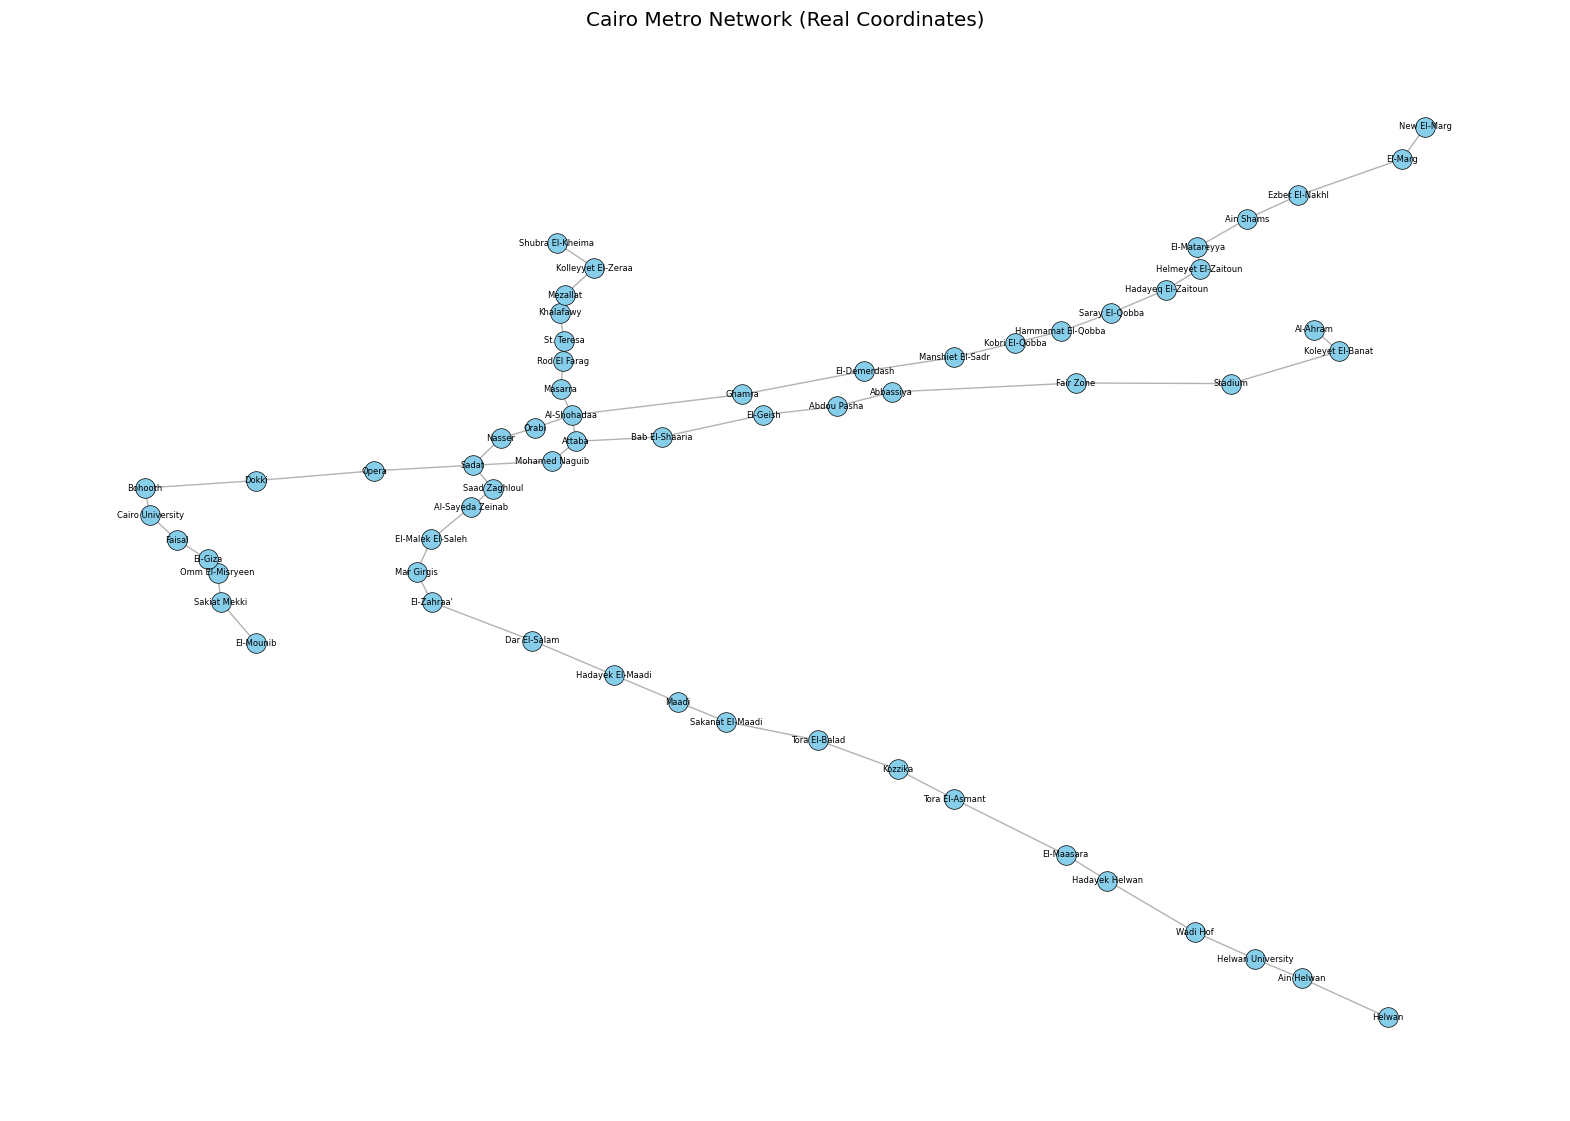

In [126]:
plt.figure(figsize=(20, 14))

nx.draw_networkx_edges(
    G,
    pos=station_positions,
    edge_color="gray",
    width=1,
    alpha=0.6
)

nx.draw_networkx_nodes(
    G,
    pos=station_positions,
    node_color="skyblue",
    node_size=200,
    edgecolors="black",
    linewidths=0.5
)

nx.draw_networkx_labels(
    G,
    pos=station_positions,
    labels=station_labels,
    font_size=6
)

plt.title("Cairo Metro Network (Real Coordinates)")
plt.axis("off")
plt.show()

# 4. Exploratory Network Analysis

This section explores the structural properties of the Cairo Metro network.

The analysis includes:
- Degree distribution
- Connectivity check
- Basic network statistics
- Centrality analysis

## Degree Distribution

The degree of a node represents the number of direct connections a station has with neighboring stations.

This analysis helps identify:
- Regular stations
- Highly connected hub stations

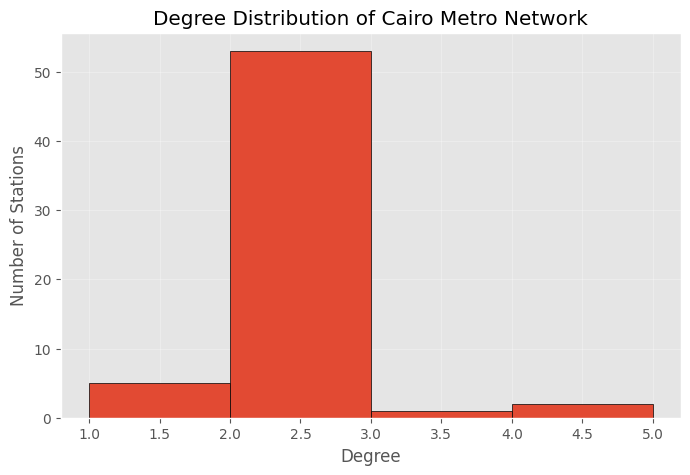

Minimum Degree: 1
Maximum Degree: 4
Average Degree: 2.0


In [127]:
# Degree distribution

degrees = [degree for node, degree in G.degree()]

plt.figure(figsize=(8, 5))

plt.hist(
    degrees,
    bins=range(min(degrees), max(degrees) + 2),
    edgecolor="black"
)

plt.xlabel("Degree")
plt.ylabel("Number of Stations")
plt.title("Degree Distribution of Cairo Metro Network")
plt.grid(True, alpha=0.3)

plt.show()

print("Minimum Degree:", min(degrees))
print("Maximum Degree:", max(degrees))
print("Average Degree:", round(np.mean(degrees), 2))

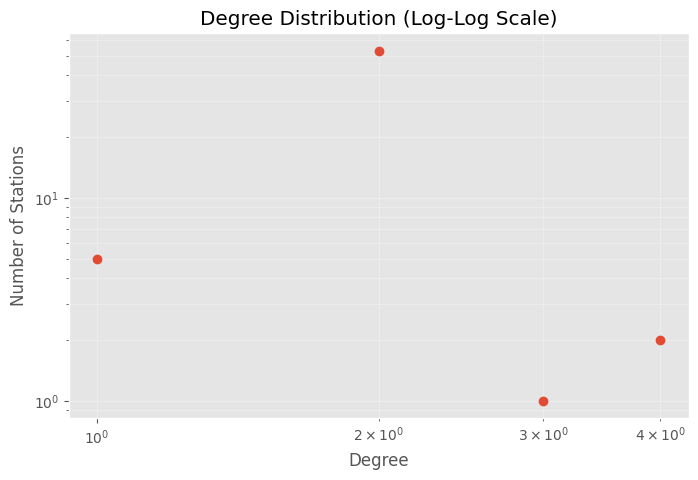

In [128]:
# Log-log degree distribution

degree_counts = np.bincount(degrees)
degree_values = np.arange(len(degree_counts))

plt.figure(figsize=(8, 5))

plt.loglog(
    degree_values[1:],
    degree_counts[1:],
    marker="o",
    linestyle="None"
)

plt.xlabel("Degree")
plt.ylabel("Number of Stations")
plt.title("Degree Distribution (Log-Log Scale)")
plt.grid(True, which="both", alpha=0.3)

plt.show()

## Connectivity Check

This step checks whether the metro network is fully connected.

If the network is disconnected, the Giant Connected Component (GCC) is used for further analysis.

In [129]:
# Check connectivity
# Connectivity check

is_connected = nx.is_connected(G)

print("Is the metro network connected?", is_connected)

if is_connected:
    gcc = G.copy()
else:
    gcc = G.subgraph(
        max(nx.connected_components(G), key=len)
    ).copy()

print("GCC Nodes:", gcc.number_of_nodes())
print("GCC Edges:", gcc.number_of_edges())
#The Cairo Metro network is fully connected, meaning every station can be reached from any other
#  station through the metro system.

Is the metro network connected? True
GCC Nodes: 61
GCC Edges: 61


## Basic Network Statistics

This section computes important structural properties of the metro network.

In [130]:
# Basic network statistics

N = G.number_of_nodes()
E = G.number_of_edges()
avg_degree = sum(dict(G.degree()).values()) / N
density = nx.density(G)
clustering = nx.average_clustering(G)
diameter = nx.diameter(gcc)

print("Number of Nodes:", N)
print("Number of Edges:", E)
print("Average Degree:", round(avg_degree, 2))
print("Network Density:", round(density, 4))
print("Average Clustering Coefficient:", round(clustering, 4))
print("Network Diameter:", diameter)

Number of Nodes: 61
Number of Edges: 61
Average Degree: 2.0
Network Density: 0.0333
Average Clustering Coefficient: 0.0
Network Diameter: 34


In [131]:
# Mapping station IDs to station names

station_name_map = dict(
    zip(stations["station_id"], stations["stop_name"])
)

## Degree Centrality

Degree centrality identifies stations with the highest number of direct connections. #مين أكتر محطات connected؟

In [132]:
# Degree centrality

degree_centrality = nx.degree_centrality(G)

top_degree = sorted(
    degree_centrality.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

print("Top 10 Stations by Degree Centrality:\n")

for station_id, value in top_degree:
    station_name = station_name_map.get(station_id, station_id)
    print(f"{station_name}: {value:.4f}")

Top 10 Stations by Degree Centrality:

Sadat: 0.0667
Al-Shohadaa: 0.0667
Attaba: 0.0500
Ain Helwan: 0.0333
Helwan University: 0.0333
Wadi Hof: 0.0333
Hadayek Helwan: 0.0333
El-Maasara: 0.0333
Tora El-Asmant: 0.0333
Kozzika: 0.0333


## Betweenness Centrality

Betweenness centrality identifies stations that act as bridges between different parts of the network.

In [133]:
# Betweenness centrality

betweenness_centrality = nx.betweenness_centrality(G)

top_betweenness = sorted(
    betweenness_centrality.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

print("Top 10 Stations by Betweenness Centrality:\n")

for station_id, value in top_betweenness:
    station_name = station_name_map.get(station_id, station_id)
    print(f"{station_name}: {value:.4f}")

Top 10 Stations by Betweenness Centrality:

Sadat: 0.5983
Al-Shohadaa: 0.5113
Attaba: 0.4133
Saad Zaghloul: 0.4130
Al-Sayeda Zeinab: 0.3977
El-Malek El-Saleh: 0.3814
Mar Girgis: 0.3638
El-Zahraa': 0.3452
Dar El-Salam: 0.3254
Ghamra: 0.3254


# 5. Network Robustness Testing

This section tests how well the Cairo Metro network survives station failures.

Two scenarios are compared:
- Random Failures: stations are removed randomly.
- Targeted Attacks: highest-degree stations are removed first.

The metric used is the size of the Largest Connected Component (LCC) as a percentage of the original network size.

In [134]:
import random

def random_failure(G):
    G = G.to_undirected()
    N = G.number_of_nodes()
    steps = 25
    M = max(1, N // steps)

    C = G.copy()
    removed_counts = []
    lcc_ratios = []

    for removed in range(0, N, M):

        if C.number_of_nodes() == 0:
            break

        largest_component = max(nx.connected_components(C), key=len)
        lcc_ratio = len(largest_component) / N

        removed_counts.append(removed)
        lcc_ratios.append(lcc_ratio)

        nodes_to_remove = random.sample(
            list(C.nodes()),
            min(M, C.number_of_nodes())
        )

        C.remove_nodes_from(nodes_to_remove)

    return removed_counts, lcc_ratios

In [135]:
def targeted_attack(G):
    G = G.to_undirected()
    N = G.number_of_nodes()
    steps = 25
    M = max(1, N // steps)

    C = G.copy()
    removed_counts = []
    lcc_ratios = []

    for removed in range(0, N, M):

        if C.number_of_nodes() == 0:
            break

        largest_component = max(nx.connected_components(C), key=len)
        lcc_ratio = len(largest_component) / N

        removed_counts.append(removed)
        lcc_ratios.append(lcc_ratio)

        nodes_sorted_by_degree = sorted(
            C.nodes(),
            key=C.degree,
            reverse=True
        )

        nodes_to_remove = nodes_sorted_by_degree[:M]

        C.remove_nodes_from(nodes_to_remove)

    return removed_counts, lcc_ratios

In [136]:
random.seed(42)

num_removed_random, random_results = random_failure(G)
num_removed_targeted, targeted_results = targeted_attack(G)

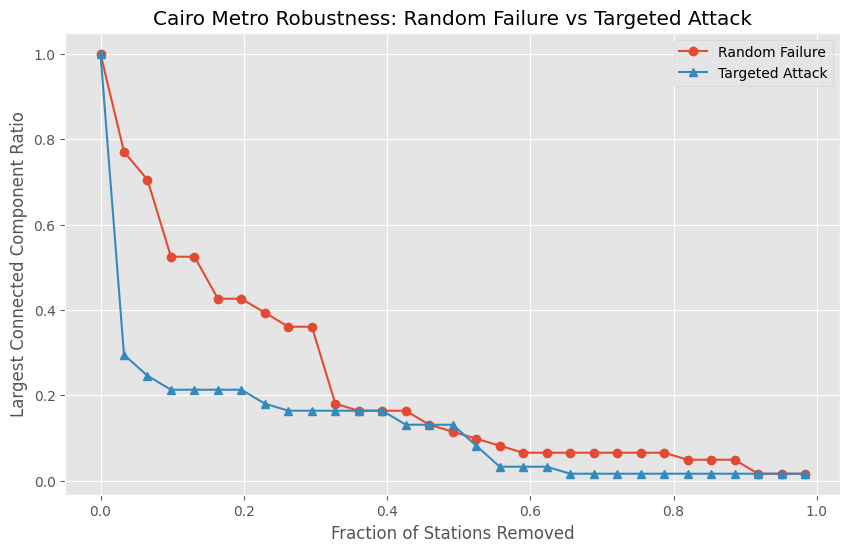

In [137]:
plt.figure(figsize=(10, 6))

plt.plot(
    [x / G.number_of_nodes() for x in num_removed_random],
    random_results,
    marker="o",
    label="Random Failure"
)

plt.plot(
    [x / G.number_of_nodes() for x in num_removed_targeted],
    targeted_results,
    marker="^",
    label="Targeted Attack"
)

plt.title("Cairo Metro Robustness: Random Failure vs Targeted Attack")
plt.xlabel("Fraction of Stations Removed")
plt.ylabel("Largest Connected Component Ratio")
plt.legend()
plt.grid(True)

plt.show()

In [138]:
station_name_map = dict(
    zip(stations["station_id"], stations["stop_name"])
)

top_degree_stations = sorted(
    G.degree(),
    key=lambda x: x[1],
    reverse=True
)[:10]

print("Top stations targeted first:")

for station_id, degree in top_degree_stations:
    station_name = station_name_map.get(station_id, station_id)
    print(f"{station_name}: Degree {degree}")

Top stations targeted first:
Sadat: Degree 4
Al-Shohadaa: Degree 4
Attaba: Degree 3
Ain Helwan: Degree 2
Helwan University: Degree 2
Wadi Hof: Degree 2
Hadayek Helwan: Degree 2
El-Maasara: Degree 2
Tora El-Asmant: Degree 2
Kozzika: Degree 2


The targeted attack curve drops faster than the random failure curve. This means that the Cairo Metro network is more vulnerable when important transfer stations are removed first, compared to random station failures.

# 6. Community Detection

Community detection identifies groups of stations that are more strongly connected to each other than to the rest of the network.

In this project, communities may represent metro lines or connected regions inside the Cairo Metro network.

In [139]:
# Community Detection using Girvan-Newman

G_undir = G.to_undirected()

communities_generator = nx.community.girvan_newman(G_undir)

# Get first split into 5 communities
for communities in communities_generator:
    communities = list(communities)
    if len(communities) == 5:
        break

modularity_score = nx.community.modularity(G_undir, communities)

print("Number of Communities:", len(communities))
print("Modularity Score:", round(modularity_score, 3))



Number of Communities: 5
Modularity Score: 0.715


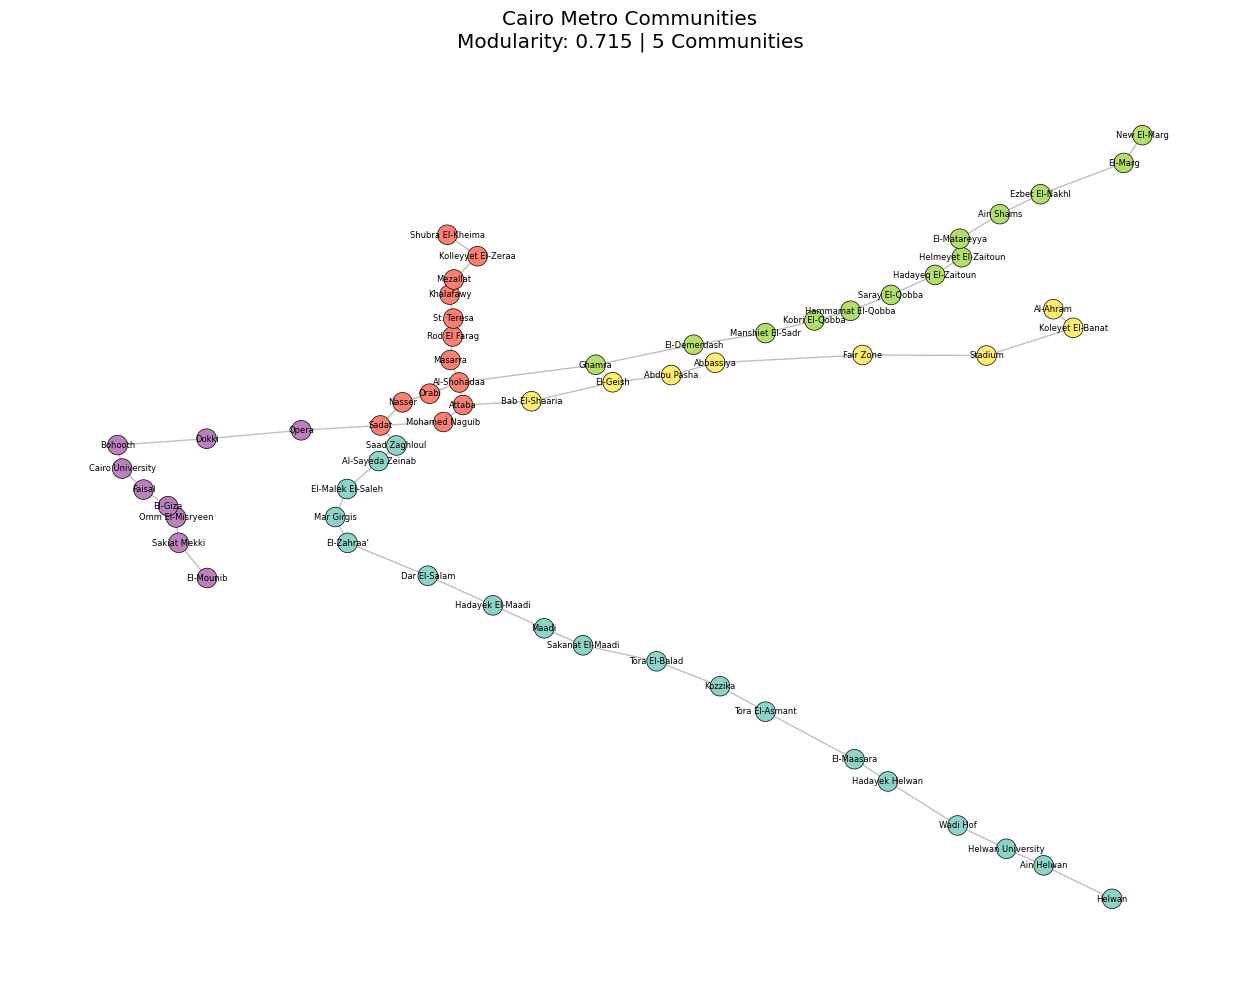

In [140]:
# Map each station to its community
community_map = {}

for i, community in enumerate(communities):
    for station in community:
        community_map[station] = i

node_colors = [community_map[node] for node in G_undir.nodes()]

plt.figure(figsize=(16, 12))

#


nx.draw_networkx_labels(
    G,
    pos=station_positions,
    labels=station_labels,
    font_size=6
)
#
nx.draw_networkx_edges(
    G_undir,
    pos=station_positions,
    edge_color="gray",
    alpha=0.5
)

nx.draw_networkx_nodes(
    G_undir,
    pos=station_positions,
    node_color=node_colors,
    cmap=plt.cm.Set3,
    node_size=200,
    edgecolors="black"
)

plt.title(
    f"Cairo Metro Communities\nModularity: {modularity_score:.3f} | {len(communities)} Communities"
)

plt.axis("off")
plt.show()

## Community Detection Interpretation

The modularity score shows how strong the detected community structure is.

If the modularity score is greater than 0.3, this indicates a clear community structure.

In the Cairo Metro network, the detected communities represent connected station groups or metro line segments. Transfer stations connect these communities together.

# 7. Information Spread Simulation

This section simulates how information, congestion, or rumors may propagate through the Cairo Metro network.

We use the SIR model:
- S: Susceptible stations
- I: Active spreading stations
- R: Recovered stations

The simulation starts from 5 random seed stations and runs for 50 time steps.

In [141]:
params = {
    "beta": 0.3,
    "gamma": 0.1
}

steps = 50
seed_count = 1

np.random.seed(42)

In [142]:
nodes = list(G.nodes())

initial_seeds = set(
    np.random.choice(nodes, seed_count, replace=False)
)

susceptible = set(nodes) - initial_seeds
infected = set(initial_seeds)
recovered = set()

S_counts = []
I_counts = []
R_counts = []
new_spread_counts = []

In [143]:
for step in range(steps):

    S_counts.append(len(susceptible))
    I_counts.append(len(infected))
    R_counts.append(len(recovered))

    new_infected = set()
    new_recovered = set()

    for station in infected:

        for neighbor in G.neighbors(station):

            if neighbor in susceptible and np.random.random() < params["beta"]:
                new_infected.add(neighbor)

        if np.random.random() < params["gamma"]:
            new_recovered.add(station)

    new_spread_counts.append(len(new_infected))

    infected = (infected | new_infected) - new_recovered
    susceptible = susceptible - new_infected
    recovered = recovered | new_recovered

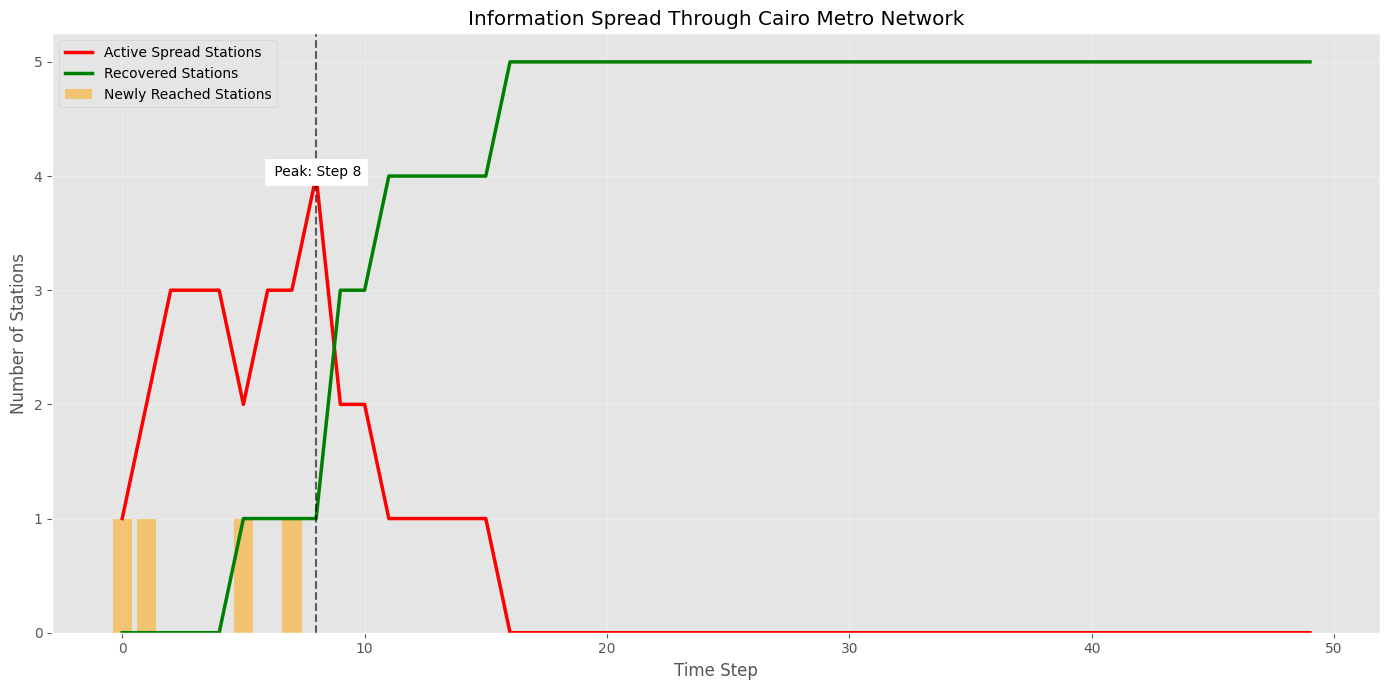

In [144]:
plt.figure(figsize=(14, 7))

plt.plot(I_counts, color="red", linewidth=2.5, label="Active Spread Stations")
plt.plot(R_counts, color="green", linewidth=2.5, label="Recovered Stations")
plt.bar(
    range(steps),
    new_spread_counts,
    color="orange",
    alpha=0.5,
    label="Newly Reached Stations"
)

peak_step = np.argmax(I_counts)
peak_value = I_counts[peak_step]

plt.axvline(peak_step, color="black", linestyle="--", alpha=0.6)
plt.text(
    peak_step,
    peak_value,
    f" Peak: Step {peak_step}",
    ha="center",
    backgroundcolor="white"
)

plt.xlabel("Time Step")
plt.ylabel("Number of Stations")
plt.title("Information Spread Through Cairo Metro Network")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [145]:
total_reached = len(recovered | infected)
final_spread_ratio = total_reached / G.number_of_nodes()

print("Information Spread Dynamics:")
print("Initial seed stations:", seed_count)
print("Peak active spread step:", peak_step)
print("Peak active stations:", peak_value)
print("Total reached stations:", total_reached)
print("Final spread ratio:", round(final_spread_ratio, 3))

Information Spread Dynamics:
Initial seed stations: 1
Peak active spread step: 8
Peak active stations: 4
Total reached stations: 5
Final spread ratio: 0.082


In [146]:
station_name_map = dict(
    zip(stations["station_id"], stations["stop_name"])
)

print("Initial Seed Stations:")

for station in initial_seeds:
    print("-", station_name_map.get(station, station))

Initial Seed Stations:
- Helwan
